### Normalize and correct sgRNA Log Fold Change data
#### adapted from Fortin et al, 2019
#### by Stefanus Bernard

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from function_to_normalize_sgRNA_LFC import *

#### Process Avana LFC and library data

In [ ]:
lfc_data = pd.read_csv("./avana_data/AvanaLogfoldChange_25Q2.csv")
lfc_data = lfc_data.rename(columns={lfc_data.columns[0]: 'spacer'})
lfc_data.head(25)

In [ ]:
library_data = pd.read_csv("../../CRISPR-KO-library-refinement-pipeline/public_crispr_library/avana_library.tsv", sep ="\t", header = None)
library_data.columns = ['sgRNA', 'spacer', 'gene']
library_data.shape

(71826, 3)

In [5]:
lfc = pd.merge(lfc_data, library_data, how="left", on="spacer").set_index(['sgRNA', 'spacer', 'gene']).sort_values(by="gene")
lfc

Colo699-311cas9-RepA-p6_Avana-4  \
sgRNA    spacer               gene                                    
sgA1BG_1 GGAAGTCTGGAGTCTCCAGG A1BG                        -0.257686   
sgA1BG_2 GTGGACTTCCAGCTACGGCG A1BG                         0.233408   
sgA1BG_4 TCAATGGTCACAGTAGCGCT A1BG                         0.023756   
sgA1BG_3 GTGTGCCGAGGTGTGCTGCG A1BG                         0.014280   
sgA1CF_2 GGAATCAAATCACAAATCCG A1CF                         0.054652   
...                                                             ...   
NaN      TTTGTGTATTACCTCAGGAA NaN                         -0.347602   
         TTTTACCTTGTTCACATGGA NaN                          0.085937   
         TTTTGACTCTAATCACCGGT NaN                          0.004612   
         TTTTTAATACAAGGTAATCT NaN                         -0.007124   
         TTTTTCTCACCCGATGAATC NaN                          0.033292   

                                    Colo699-311cas9-RepB-p6_Avana-4  \
sgRNA    spacer               gene                                    
sgA1BG_1 GGAAGTCTGGAGTCTCCAGG A1BG                        -0.298174   
sgA1BG_2 GTGGACTTCCAGCTACGGCG A1BG                         0.299895   
sgA1BG_4 TCAATGGTCACAGTAGCGCT A1BG                        -0.473843   
sgA1BG_3 GTGTGCCGAGGTGTGCTGCG A1BG                        -0.324734   
sgA1CF_2 GGAATCAAATCACAAATCCG A1CF                        -0.087523   
...                                                             ...   
NaN      TTTGTGTATTACCTCAGGAA NaN                          0.320081   
         TTTTACCTTGTTCACATGGA NaN                          0.292619   
         TTTTGACTCTAATCACCGGT NaN                         -0.385894   
         TTTTTAATACAAGGTAATCT NaN                          0.154439   
         TTTTTCTCACCCGATGAATC NaN                         -0.138348   

                                    HSB-2-311cas9_RepA_p4_Avana-3  \
sgRNA    spacer               gene                                  
sgA1BG_1 GGAAGTCTGGAGTCTCCAGG A1BG                       0.226088   
sgA1BG_2 GTGGACTTCCAGCTACGGCG A1BG                       0.425173   
sgA1BG_4 TCAATGGTCACAGTAGCGCT A1BG                      -0.419967   
sgA1BG_3 GTGTGCCGAGGTGTGCTGCG A1BG                       0.235696   
sgA1CF_2 GGAATCAAATCACAAATCCG A1CF                      -0.405659   
...                                                           ...   
NaN      TTTGTGTATTACCTCAGGAA NaN                       -0.042124   
         TTTTACCTTGTTCACATGGA NaN                        0.207097   
         TTTTGACTCTAATCACCGGT NaN                        0.182117   
         TTTTTAATACAAGGTAATCT NaN                       -0.221927   
         TTTTTCTCACCCGATGAATC NaN                       -0.256905   

                                    HSB-2-311cas9_RepB_p4_Avana-3  \
sgRNA    spacer               gene                                  
sgA1BG_1 GGAAGTCTGGAGTCTCCAGG A1BG                       0.030155   
sgA1BG_2 GTGGACTTCCAGCTACGGCG A1BG                       0.251597   
sgA1BG_4 TCAATGGTCACAGTAGCGCT A1BG                      -0.159187   
sgA1BG_3 GTGTGCCGAGGTGTGCTGCG A1BG                      -0.686056   
sgA1CF_2 GGAATCAAATCACAAATCCG A1CF                      -0.322912   
...                                                           ...   
NaN      TTTGTGTATTACCTCAGGAA NaN                       -0.290717   
         TTTTACCTTGTTCACATGGA NaN                        0.210888   
         TTTTGACTCTAATCACCGGT NaN                        0.221753   
         TTTTTAATACAAGGTAATCT NaN                       -0.152003   
         TTTTTCTCACCCGATGAATC NaN                       -0.251676   

                                    NCIH1339-311Cas9_RepA_p6_Avana-3  \
sgRNA    spacer               gene                                     
sgA1BG_1 GGAAGTCTGGAGTCTCCAGG A1BG                          0.195384   
sgA1BG_2 GTGGACTTCCAGCTACGGCG A1BG                         -0.004233   
sgA1BG_4 TCAATGGTCACAGTAGCGCT A1BG                          0.235672   
sgA1BG_3 GTGTGCCGAGGTGTGCTGCG A1

In [6]:
# normalize data by median
lfc_norm = lfc.apply(normalize_column, axis=0)

Scale factor:  1.2376473275775624


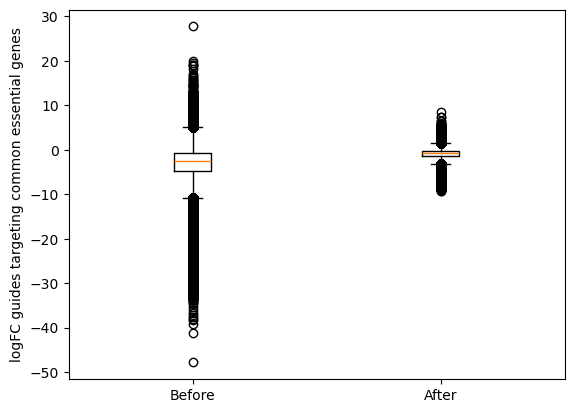

In [7]:
lfc_norm_scaled, list_common_essential = scale_essential(lfc)
sanity_check_scale_essential(lfc_norm, lfc_norm_scaled, list_common_essential)


In [8]:
lfc_norm_scaled_avg = mean_row(lfc_norm_scaled)
lfc_norm_scaled_avg = lfc_norm_scaled_avg.reset_index()
lfc_norm_scaled_avg

,sgRNA,spacer,gene,mean
0,sgA1BG_1,GGAAGTCTGGAGTCTCCAGG,A1BG,0.000033
1,sgA1BG_2,GTGGACTTCCAGCTACGGCG,A1BG,0.241808
2,sgA1BG_4,TCAATGGTCACAGTAGCGCT,A1BG,-0.089741
3,sgA1BG_3,GTGTGCCGAGGTGTGCTGCG,A1BG,0.051367
4,sgA1CF_2,GGAATCAAATCACAAATCCG,A1CF,-0.096843
...,...,...,...,...
76422,NaN,TTTGTGTATTACCTCAGGAA,NaN,0.015253
76423,NaN,TTTTACCTTGTTCACATGGA,NaN,0.335777
76424,NaN,TTTTGACTCTAATCACCGGT,NaN,0.173447
76425,NaN,TTTTTAATACAAGGTAATCT,NaN,0.248071


In [ ]:
lfc_norm_scaled_avg.to_csv("./output_normalized/avana_normalized_lfc.csv", index=False)